In [100]:
pip install plotly

  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/52/d2/c6e44dba74f17c6216ce1b56044a9b93a929f1c2d5bdaff892512b260f5e/plotly-6.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=1.15.1 from https://files.pythonhosted.org/packages/fe/75/0b4a10da17a44cf13567d08a9c7632a285297e46253263f1ae119129d10a/narwhals-2.18.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
    --------------------------------------- 0.2/9.9 MB 3.5 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.9 MB 10.5 MB/s eta 0:00:01
   ----------- ---------------------------- 2.9/9.9 MB 20.7 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 30.4 MB/s eta 0:00:01
   ---------------------------- ----------- 7.2/9.9 MB 32.7 MB/s eta 0:00:01
   ------------------------------------ --- 9.1/9.9 MB 34.3 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 35.2 MB/

In [159]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# EDA

In [119]:
features = pd.read_csv('../data/features.txt', sep='\s+', header=None, names=['index', 'feature_name'])

X = pd.read_csv('../data/train/X_train.txt', sep='\s+', header=None)
y = pd.read_csv('../data/train/y_train.txt', sep='\s+', header=None, names=['activity'])

subjects = pd.read_csv('../data/train/subject_train.txt', sep='\s+', header=None, names=['subject'])
activity_labels = pd.read_csv('../data/activity_labels.txt', sep='\s+', header=None, names=['index', 'activity_name'])

In [134]:
RANDOM_SEED = 123

In [135]:
X, y, subjects = shuffle(X, y, subjects, random_state=RANDOM_SEED)

In [136]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 7352
Number of features: 561


In [156]:
print("Activity labels:\n\n", activity_labels.activity_name.to_string(index=False))

Activity labels:

            WALKING
  WALKING_UPSTAIRS
WALKING_DOWNSTAIRS
           SITTING
          STANDING
            LAYING


In [ ]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum().sum())
print("Missing values in subjects:", subjects.isnull().sum().sum())

Missing values in X: 0
Missing values in y: 0
Missing values in subjects: 0


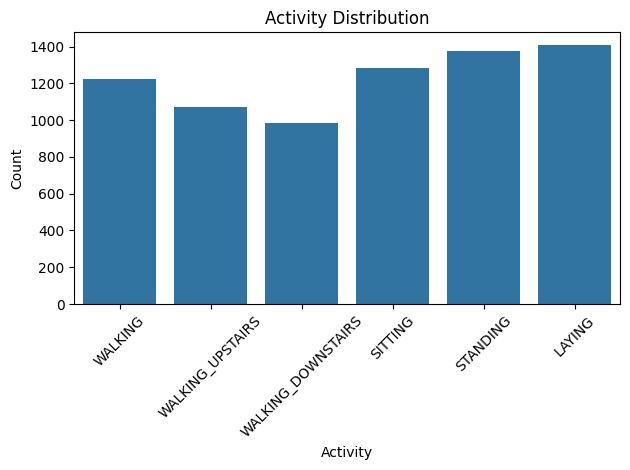

activity
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [ ]:
activity_counts = y['activity'].value_counts().sort_index()

plt.figure()
sns.barplot(x=activity_labels.activity_name, y=activity_counts.values)

plt.title("Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(activity_counts)

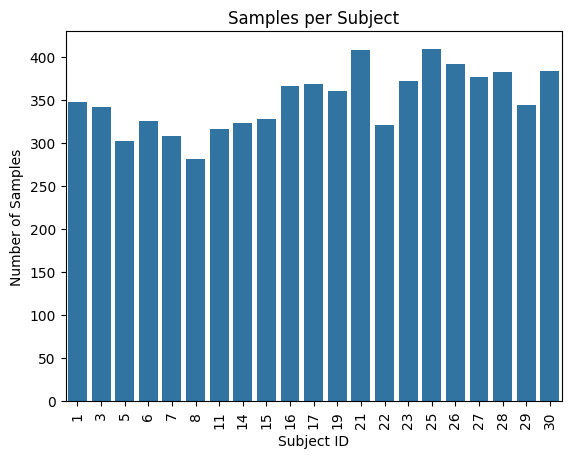

subject
1     347
3     341
5     302
6     325
7     308
8     281
11    316
14    323
15    328
16    366
17    368
19    360
21    408
22    321
23    372
25    409
26    392
27    376
28    382
29    344
30    383
Name: count, dtype: int64


In [139]:
subject_counts = subjects['subject'].value_counts().sort_index()

plt.figure()
sns.barplot(x=subject_counts.index, y=subject_counts.values)

plt.title("Samples per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.show()

print(subject_counts)

In [ ]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['activity'] = y.activity

In [141]:
activity_map = {}
for i, name in enumerate(activity_labels.activity_name):
    activity_map[i+1] = name

pca_df['activity_name'] = pca_df['activity'].map(activity_map)

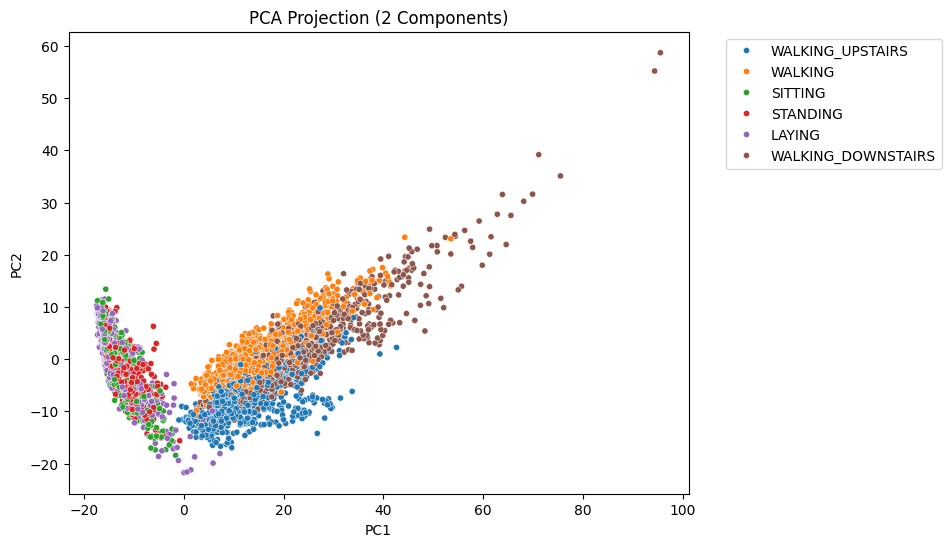

In [142]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='activity_name',
    data=pca_df,
    palette='tab10',
    s=20
)

plt.title("PCA Projection (2 Components)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

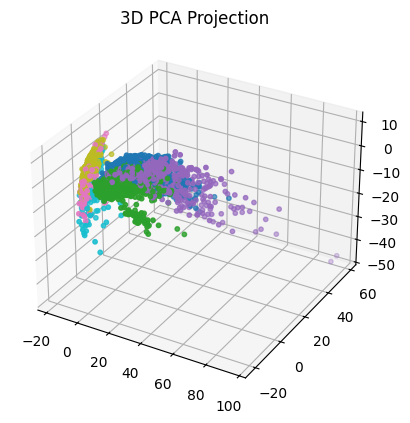

In [143]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=y['activity'],
    cmap='tab10',
    s=10
)

ax.set_title("3D PCA Projection")
plt.show()

In [144]:
import plotly.express as px

pca_df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['activity'] = pca_df['activity_name']  # use names

fig = px.scatter_3d(
    pca_df_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='activity',
    title='Interactive 3D PCA Projection'
)

fig.show()

In [ ]:
# 99% variance
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_scaled)

print("Number of components selected:", pca.n_components_)

Number of components selected: 179


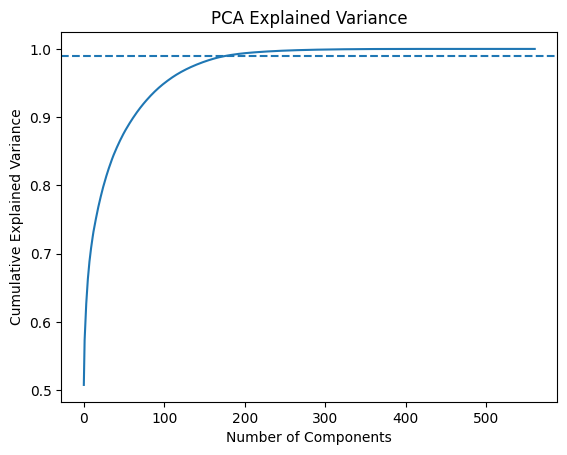

In [146]:
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(cum_var)
plt.axhline(y=0.99, linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [ ]:
# Label encoding

le = LabelEncoder()
y_encoded = le.fit_transform(y['activity']) 
y_encoded

array([1, 0, 3, ..., 5, 4, 1], dtype=int64)